# normattiva-sdk in pratica

Normattiva pubblica il testo delle leggi italiane e, a differenza di quasi ogni
altra fonte, conserva il testo che ogni legge aveva in una data qualunque del
passato. Questo notebook usa
[normattiva-sdk](https://github.com/ireneburresi/normattiva-sdk) per
interrogare proprio questo: come è cambiata una norma, chi l'ha cambiata e
quando.

Le celle interrogano il servizio reale. Si eseguono dall'alto in basso e
richiedono una connessione; gli output salvati sono quelli del
**25 agosto 2026**.

> **Libreria non ufficiale della comunità**, non affiliata con IPZS né con la
> Presidenza del Consiglio dei Ministri. I dati sono di IPZS in licenza
> **CC BY 4.0**: il testo **non è autentico**, l'unico ufficiale è quello
> pubblicato sulla Gazzetta Ufficiale a mezzo stampa.

## Prepararsi

La libreria ha una sola dipendenza, `httpx`. Questo notebook ne usa altre due,
`pandas` e `matplotlib`, che servono al notebook e non alla libreria: mostrano
come i modelli passano in una tabella e in un grafico.

```bash
pip install normattiva-sdk pandas matplotlib
```

Su Colab o su un kernel appena creato, la stessa riga preceduta da `%pip`.

In [1]:
from datetime import date

import matplotlib.pyplot as plt
import pandas as pd

from normattiva import ATTRIBUZIONE, Normattiva, codici
from normattiva.errori import AmbiguityError

normattiva = Normattiva()
normattiva.base_url

'https://api.normattiva.it/t/normattiva.api/bff-opendata/v1/api/v1'

Il client tiene aperto un pool di connessioni e si autolimita a due richieste
al secondo. Conviene costruirne uno solo e riutilizzarlo: due client sono due
budget di richieste indipendenti verso lo stesso servizio. Alla fine del
notebook lo chiudiamo.

Nessuna chiave, nessun token, nessuna registrazione: l'API open data risponde
senza autenticazione.

## Il primo articolo

Gli articoli dei codici non rispondono sotto il decreto che li ha approvati, ma
sotto l'allegato in cui furono pubblicati, e l'allegato cambia da codice a
codice. `codici` contiene la mappa, verificata contro il servizio.

In [2]:
bersaglio = codici.CODICE_CIVILE.articolo(2043)
print(bersaglio)  # il :2 in mezzo è l'allegato

art2043 = normattiva.dettaglio(bersaglio)
print(art2043.atto.citazione)
print()
print(art2043.testo)

urn:nir:stato:regio.decreto:1942-03-16;262:2~art2043
R.D. 16 marzo 1942, n. 262

Art. 2043.
(Risarcimento per fatto illecito).
Qualunque fatto doloso o colposo, che cagiona ad altri un danno ingiusto, obbliga colui che ha commesso il fatto a risarcire il danno.


## La stessa norma a date diverse

Qui comincia la funzionalità che altrove non si trova. L'articolo 19 della
legge sul procedimento amministrativo, la 241 del 1990, è la norma che ha
introdotto quella che oggi si chiama SCIA. È stato riscritto molte volte, e a
ogni riscrittura ha cambiato nome e sostanza.

Chiediamolo a tre date lontane fra loro.

In [3]:
ART19 = "urn:nir:stato:legge:1990-08-07;241~art19"

istantanee = []
for quando in [date(1995, 1, 1), date(2008, 1, 1), date(2024, 1, 1)]:
    versione = normattiva.dettaglio(ART19, vigenza=quando)
    istantanee.append(
        {
            "chiesto": quando,
            "in vigore dal": versione.finestra.inizio,
            "fino al": versione.finestra.fine,
            "caratteri": len(versione.testo),
            "attacco": versione.testo[:70].replace("\n", " ") + "...",
        }
    )

pd.DataFrame(istantanee)

,chiesto,in vigore dal,fino al,caratteri,attacco
0,1995-01-01,1994-01-01,2005-03-07,1618,Art. 19 ((1. In tutti i casi in cui l'esercizi...
1,2008-01-01,2005-05-15,2009-07-03,3344,Art. 19 ((Dichiarazione di inizio attività.)) ...
2,2024-01-01,2020-05-19,2026-02-19,6198,Art. 19 (Segnalazione certificata di inizio at...


Nessuna delle date restituite è quella richiesta, ed è il comportamento
corretto: si chiede una data e il servizio risponde con la finestra di vigenza
che la contiene. La libreria verifica che quella finestra copra davvero la data
richiesta, e solleva `ValidityMismatchError` quando non la copre.

Senza `vigenza` si ottiene il testo di oggi. È legittimo, ma resta una scelta
visibile nella firma: nella risposta non c'è nulla che distingua «ho chiesto
oggi» da «non ho chiesto niente».

## Tutta la storia di un articolo

`cronologia` percorre le versioni dall'originale a quella in vigore. Costa una
richiesta per versione e l'articolo 19 ne ha sessantuno, quindi qui ne
chiediamo dodici.

In [4]:
versioni = list(normattiva.cronologia(ART19, massimo=12))

storia = pd.DataFrame(
    {
        "dal": v.finestra.inizio,
        "al": v.finestra.fine,
        "caratteri": len(v.testo),
        "modificata da": (v.note_aggiornamento or "")[:60],
    }
    for v in versioni
)
storia

,dal,al,caratteri,modificata da
0,1990-09-02,1992-06-10,2205,
1,1992-06-11,1993-12-31,3001,
2,1994-01-01,2005-03-07,1618,
3,2005-03-08,2005-05-14,2440,
4,2005-05-15,2009-07-03,3344,
5,2009-07-04,2010-05-07,5046,
6,2010-05-08,2010-07-30,4826,
7,2010-07-31,2010-09-15,4994,
8,2010-09-16,2010-10-05,5121,
9,2010-10-06,2011-07-12,5485,


Le finestre si susseguono senza buchi: la fine di una è il giorno prima
dell'inizio della successiva. È questa proprietà che permette a `cronologia` di
passare da una versione all'altra; se un giorno smettesse di valere, la
libreria solleverebbe un errore invece di ciclare a vuoto.

Messe su un asse temporale si vede quello che una tabella nasconde: i periodi
di stabilità e le serie ravvicinate di modifiche.

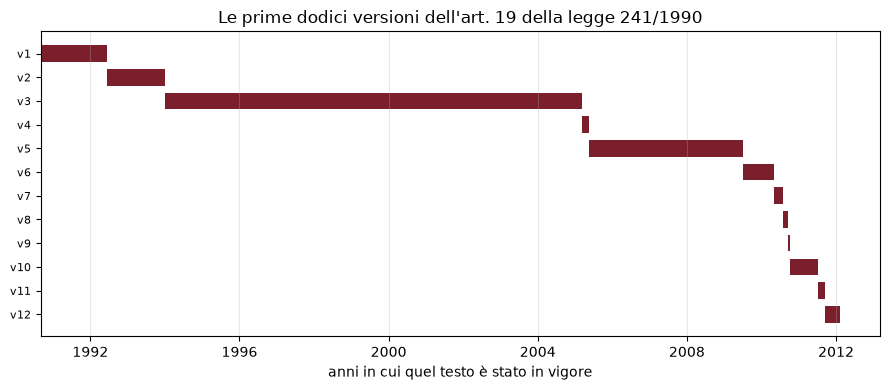

In [5]:
oggi = date.today()
inizi = [v.finestra.inizio for v in versioni]
durate = [((v.finestra.fine or oggi) - v.finestra.inizio).days for v in versioni]

figura, asse = plt.subplots(figsize=(9, 4))
asse.barh(range(len(versioni)), durate, left=inizi, height=0.7, color="#7a1f2b")
asse.set_yticks(range(len(versioni)))
asse.set_yticklabels([f"v{n}" for n in range(1, len(versioni) + 1)], fontsize=8)
asse.invert_yaxis()
asse.set_xlabel("anni in cui quel testo è stato in vigore")
asse.set_title("Le prime dodici versioni dell'art. 19 della legge 241/1990")
asse.grid(axis="x", alpha=0.3)
figura.tight_layout()
plt.show()

## Cercare, e mettere i risultati in una tabella

`ricerca_completa` scorre le pagine automaticamente, una per volta, ed è lazy:
consumarne dieci risultati costa una richiesta sola. `massimo` interrompe dopo
quel numero di atti.

I modelli sono `dataclass` congelate, quindi passano in un `DataFrame`
direttamente: basta scegliere i campi che interessano.

In [6]:
trovati = list(normattiva.ricerca_completa("silenzio assenso", massimo=25))

tabella = pd.DataFrame(
    {
        "citazione": t.estremi.citazione,
        "anno": t.estremi.data.year,
        "tipo": t.estremi.denominazione,
        "urn": str(t.urn) if t.ha_urn else None,
        "titolo": (t.titolo or "")[:70],
    }
    for t in trovati
)
tabella.head(10)

,citazione,anno,tipo,urn,titolo
0,"L. 20 aprile 2026, n. 50",2026,LEGGE,urn:nir:stato:legge:2026-04-20;50,"Conversione in legge, con modificazioni, del d..."
1,"D.L. 19 febbraio 2026, n. 19",2026,DECRETO-LEGGE,urn:nir:stato:decreto.legge:2026-02-19;19,Ulteriori disposizioni urgenti per l'attuazion...
2,"L. 2 dicembre 2025, n. 182",2025,LEGGE,urn:nir:stato:legge:2025-12-02;182,Disposizioni per la semplificazione e la digit...
3,"D.P.R. 24 marzo 2025, n. 53",2025,DECRETO DEL PRESIDENTE DELLA REPUBBLICA,urn:nir:stato:decreto.del.presidente.della.rep...,Recepimento degli accordi sindacali relativi a...
4,"D.P.R. 24 marzo 2025, n. 52",2025,DECRETO DEL PRESIDENTE DELLA REPUBBLICA,urn:nir:stato:decreto.del.presidente.della.rep...,Recepimento dell'accordo sindacale relativo al...
5,"L. 16 dicembre 2024, n. 193",2024,LEGGE,urn:nir:stato:legge:2024-12-16;193,Legge annuale per il mercato e la concorrenza ...
6,"Decreto 17 settembre 2024, n. 159",2024,DECRETO,urn:nir:stato:decreto:2024-09-17;159,"Regolamento di attuazione dell'articolo 4, com..."
7,"D.Lgs. 6 ottobre 2023, n. 148",2023,DECRETO LEGISLATIVO,urn:nir:stato:decreto.legislativo:2023-10-06;148,Adeguamento della normativa nazionale alle dis...
8,"Decreto 30 agosto 2023, n. 142",2023,DECRETO,urn:nir:stato:decreto:2023-08-30;142,Regolamento recante la disciplina delle scuole...
9,"D.L. 19 settembre 2023, n. 124",2023,DECRETO-LEGGE,urn:nir:stato:decreto.legge:2023-09-19;124,Disposizioni urgenti in materia di politiche d...


In [7]:
tabella.groupby("tipo").size().sort_values(ascending=False)

tipo
DECRETO-LEGGE                                        7
LEGGE                                                7
DECRETO LEGISLATIVO                                  5
DECRETO DEL PRESIDENTE DELLA REPUBBLICA              3
DECRETO                                              2
DECRETO DEL PRESIDENTE DEL CONSIGLIO DEI MINISTRI    1
dtype: int64

Una pagina di risultati porta anche le faccette, senza richieste aggiuntive:
arrivano nella stessa risposta. Sono i valori con cui restringere la ricerca.

In [8]:
esito = normattiva.ricerca("silenzio assenso", per_pagina=1)

print(f"{esito.totale} atti in tutto")
pd.DataFrame(
    {"codice": f.codice, "atti": f.conteggio, "descrizione": f.descrizione}
    for f in esito.faccette.per_tipo
)

65 atti in tutto


,codice,atti,descrizione
0,PLE,21,LEGGE
1,PLL,15,DECRETO LEGISLATIVO
2,PDL,14,DECRETO-LEGGE
3,PPR,8,DECRETO DEL PRESIDENTE DELLA REPUBBLICA
4,DCT,4,DECRETO
5,PDM,2,DECRETO MINISTERIALE
6,PCM_DPC,1,NaN


## Le trappole restano in vista

L'API funziona, ma in alcuni punti si comporta in modi inattesi. La libreria
non li nasconde: li trasforma in informazioni esplicite su cui decidere.

**Gli articoli lunghi vengono troncati senza avviso.** Il servizio memorizza
gli articoli a blocchi di cento commi e ne restituisce il primo, senza nessun
campo che lo dichiari. L'articolo 1 della legge di bilancio 2017 ha oltre
seicento commi.

In [9]:
bilancio = normattiva.dettaglio("urn:nir:stato:legge:2016-12-11;232~art1")

print(f"commi arrivati:        {bilancio.commi_presenti}")
print(f"ultimo comma numerato: {bilancio.ultimo_comma_numerato}")
print(f"sospetto di taglio:    {bilancio.possibile_troncamento}")

commi arrivati:        105
ultimo comma numerato: 100
sospetto di taglio:    True


Un ultimo comma che cade esattamente su un multiplo di cento è un sospetto,
non una certezza: un articolo che finisce davvero lì è indistinguibile da uno
troncato, ed è il motivo per cui la libreria segnala un sospetto e non un
verdetto. Con `se_troncato="solleva"` il sospetto diventa un'eccezione. Il
testo integrale si ottiene dall'esportazione, che non tronca.

**Lo stesso URN può indicare due atti diversi.** Il testo unico dell'edilizia
ne è un caso: due provvedimenti distinti, su Gazzette diverse, con lo stesso
titolo.

In [10]:
try:
    normattiva.dettaglio(codici.TESTO_UNICO_EDILIZIA.articolo(1))
except AmbiguityError as ambiguita:
    for candidato in ambiguita.candidati:
        print(candidato.gazzetta, "|", candidato.estremi.citazione)

G.U. n. 266 del 2001-11-15, suppl. SO n. 246 | D.P.R. 6 giugno 2001, n. 380
G.U. n. 245 del 2001-10-20, suppl. SO n. 239 | D.P.R. 6 giugno 2001, n. 380


La libreria non ne sceglie uno, e in particolare non ordina mai per lunghezza
del testo. I candidati arrivano dentro l'eccezione, quindi leggerli non costa
una richiesta in più, e si distinguono dalle coordinate di Gazzetta.

**Dodici tipi di atto su trenta non hanno una forma URN verificata**, quasi
tutti storici. I decreti-legge luogotenenziali, per esempio, sono gli atti del
governo del Regno del Sud fra il 1944 e il 1946: ce ne sono più di mille nel
corpus e nessuno è raggiungibile per URN. Per quei tipi `urn` solleva un errore
invece di costruire un identificatore che il servizio rifiuterebbe, e `ha_urn`
lo segnala in anticipo.

In [11]:
luogotenenziali = normattiva.ricerca_avanzata(
    denominazione="DECRETO-LEGGE LUOGOTENENZIALE", per_pagina=5
)
senza_urn = [t for t in luogotenenziali.atti if not t.ha_urn]

print(f"{luogotenenziali.totale} atti di questo tipo nel corpus")
print(f"{len(senza_urn)} su {len(luogotenenziali.atti)} di questa pagina non hanno un URN")
print()
for atto in senza_urn:
    print(f"  {atto.estremi.citazione:<36} {atto.gazzetta}")

1366 atti di questo tipo nel corpus
5 su 5 di questa pagina non hanno un URN

  Decreto-legge luogotenenziale 30 giugno 1944, n. 203 G.U. n. 57 del 1944-09-19
  Decreto-legge luogotenenziale 10 agosto 1944, n. 181 G.U. n. 52 del 1944-09-05
  Decreto-legge luogotenenziale 10 agosto 1944, n. 180 G.U. n. 52 del 1944-09-05
  Decreto-legge luogotenenziale 25 giugno 1944, n. 151 G.U. n. 39 del 1944-07-08
  Decreto-legge luogotenenziale 1 maggio 1919, n. 2523 G.U. n. 15 del 1920-01-20


Questi atti restano leggibili: `dettaglio` accetta direttamente un risultato
di ricerca, e per quegli atti usa le coordinate di Gazzetta, che il servizio
accetta altrettanto bene. Quel percorso però non supporta le date, e chiedere
una vigenza produce un errore esplicito invece di un parametro ignorato in
silenzio.

In [12]:
per_gazzetta = normattiva.dettaglio(senza_urn[0])

print(per_gazzetta.atto.citazione)
print(per_gazzetta.titolo)
print()
print(per_gazzetta.testo[:400], "...")

Decreto-legge luogotenenziale 30 giugno 1944, n. 203
DECRETO-LEGGE LUOGOTENENZIALE 30 giugno 1944, n. 203

Art. 1
((PROVVEDIMENTO ABROGATO DAL D.L. 22 DICEMBRE 2008, N. 200, CONVERTITO CON MODIFICAZIONI DALLA L. 18 FEBBRAIO 2009, N. 9)) ...


## Esportare un atto intero

Il percorso interattivo restituisce un articolo per volta e tronca quelli
lunghi. L'esportazione restituisce l'atto intero, con tutte le sue versioni, e
non tronca. In cambio è asincrona: si avvia, si attende, si scarica.

In [13]:
esportazione = normattiva.start_export(anno=1990, numero=241)
print("token:", esportazione.token)

esportazione.wait()
corpus = esportazione.download()

atto = corpus.atti[0]
print(
    f"{atto.estremi.citazione}: {len(atto.versioni)} versioni, "
    f"{len(atto.aggiornamenti)} aggiornamenti"
)

token: 07e1fef4-c8d6-47a7-8b5c-00cdd6080817


L. 7 agosto 1990, n. 241: 61 versioni, 60 aggiornamenti


Un `AttoStorico` risponde alla domanda centrale: che testo era in vigore in un
certo giorno.

In [14]:
vigente_nel_2005 = atto.alla_data(date(2005, 1, 1))
articoli = list(vigente_nel_2005.articoli())

print(f"in vigore dal {vigente_nel_2005.vigente_dal}, {len(articoli)} articoli")
print()
print(next(a.testo for a in articoli if a.numero == "19")[:300], "...")

in vigore dal 2004-04-29, 34 articoli

Art. 19. 
 
 ((1. In tutti i casi in cui l'esercizio di un'attivita' privata sia subordinato ad autorizzazione, licenza, abilitazione, nulla-osta, permesso o altro atto di consenso comunque denominato, ad esclusione delle concessioni edilizie e delle autorizzazioni rilasciate ai sensi delle leggi 1  ...


Il corpus si salva su disco e si riapre senza rete, con `Corpus.from_zip`. È
utile per lavorarci più volte senza richiedere al servizio la stessa cosa.

In [15]:
percorso = corpus.save("241.zip")
print(f"{percorso} ({percorso.stat().st_size / 1_048_576:.1f} MB)")

241.zip (1.6 MB)


## Chiudere, e l'attribuzione

La licenza dei dati richiede l'attribuzione, anche a chi ripubblica quello che
ha ottenuto da qui. La libreria la espone già completa: la fonte, il carattere
non autentico e quello gratuito.

In [16]:
normattiva.close()
print(ATTRIBUZIONE)

Fonte: Normattiva (https://www.normattiva.it), Istituto Poligrafico e Zecca dello Stato, in licenza CC BY 4.0. Testo non autentico e gratuito: l'unico testo ufficiale è quello pubblicato sulla Gazzetta Ufficiale a mezzo stampa.


## Dove continuare

- La [documentazione](https://github.com/ireneburresi/normattiva-sdk) con le
  guide per obiettivo, il riferimento generato dalle docstring e le dodici
  trappole verificate.
- Le stesse funzionalità dal terminale, senza scrivere Python:
  `normattiva --help`.